In [1]:
import os

from msmjax.benchmark_tools import plot_parity_line

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# os.environ["JAX_ENABLE_X64"] = "true" # TODO

from pathlib import Path

import jax
import jax.numpy as jnp
import numpy as onp
import matplotlib.pyplot as plt
from matscipy.neighbours import neighbour_list

from msmjax.calculators import (
    set_up_msm_params_static_cell,
    MSMParams,
    create_msm,
)

# Function def

In [2]:
def remove_duplicates_from_neighborlist(neighborlist):
    without_duplicates = onp.unique(
        onp.sort(onp.column_stack([neighborlist[0], neighborlist[1]]), axis=1),
        axis=0,
    )
    without_duplicates = (without_duplicates[:, 0], without_duplicates[:, 1])
    return without_duplicates

# Load data

In [3]:
DATADIR = Path.cwd().parent / "tests" / "data"

datafile = DATADIR / "nonperiodic_cubic.npz"
# datafile = DATADIR / "nonperiodic_ortho-different-sidelengths.npz"
# datafile = DATADIR / "nonperiodic_triclinic.npz"
# datafile = DATADIR / "periodic_cubic.npz"
# datafile = DATADIR / "periodic_ortho-different-sidelengths.npz"
# datafile = DATADIR / "periodic_triclinic.npz"

In [4]:
structure = onp.load(datafile)

CELL_MODE = "ortho"
PBC = (False, False, False)
LEVEL_ONE_SPACINGS = 1.0
LEVEL_ZERO_CUTOFF = 3.0

cell = structure["cell"]
pos = structure["positions"]
chg = structure["charges"]
(n_particles, n_dim) = pos.shape

energy_ref = structure["energy"]
forces_ref = structure["forces"]

# Set up

In [17]:
nbl = neighbour_list(
    "ij",
    cutoff=LEVEL_ZERO_CUTOFF,
    positions=pos,
    cell=cell,
    pbc=PBC,
)
nbl_no_duplicates = remove_duplicates_from_neighborlist(nbl)

In [6]:
msm_params = set_up_msm_params_static_cell(
    cell=cell,
    cell_mode=CELL_MODE,
    pbc=PBC,
    level_one_spacings=LEVEL_ONE_SPACINGS,
    level_zero_cutoff=LEVEL_ZERO_CUTOFF,
    n_particles=n_particles,
    use_neighborlist=True,
)

Suggested value for max grid level L was found according to criterion/criteria:
(if multiple criteria listed, that means they agree on the suggested L)
*) Highest-level grid not coarser than simulation box size ("criterion 1.")



In [7]:
msm_params.grid_shapes

[None, (27, 27, 27), (16, 16, 16), (11, 11, 11), (8, 8, 8), (7, 7, 7)]

In [8]:
msm_params.stencil_extents_from_center

[None, (7, 7, 7), (7, 7, 7), (7, 7, 7), (7, 7, 7), (6, 6, 6)]

In [9]:
msm_params.info["args_passed_during_setup"]

{'cell': array([[21.54434776,  0.        ,  0.        ],
        [ 0.        , 21.54434776,  0.        ],
        [ 0.        ,  0.        , 21.54434776]]),
 'cell_mode': 'ortho',
 'pbc': (False, False, False),
 'level_one_spacings': 1.0,
 'level_zero_cutoff': 3.0,
 'n_particles': 10000,
 'use_neighborlist': True,
 'convolution_methods': 'scipy-fft'}

# Run

In [10]:
calc_energy, calc_forces, calc_energy_and_forces, calc_charge_gradient = (
    create_msm(msm_params)
)
calc_energy = jax.jit(calc_energy)
calc_forces = jax.jit(calc_forces)
calc_energy_and_forces = jax.jit(calc_energy_and_forces)
calc_charge_gradient = jax.jit(calc_charge_gradient)

In [11]:
# calc_energy(pos, chg)
calc_energy(pos, chg, nbl_no_duplicates)

Array(-40.385986, dtype=float32)

In [12]:
# calc_forces(pos, chg)
calc_forces(pos, chg, nbl_no_duplicates)

Array([[ 0.73853356, -0.24290942, -0.35227   ],
       [-1.2355736 , -0.7407104 , -0.23328559],
       [-1.1237481 , -2.5516284 , -0.38034093],
       ...,
       [-0.30623412, -0.7893855 , -0.2452273 ],
       [ 0.91780907,  1.7972635 , -0.05917928],
       [ 1.2776372 , -0.642239  , -1.7604326 ]], dtype=float32)

In [18]:
# calc_energy_and_forces(pos, chg)
calc_energy_and_forces(pos, chg, nbl_no_duplicates)

(Array(-40.385986, dtype=float32),
 Array([[ 0.7385336 , -0.2429094 , -0.35227   ],
        [-1.2355739 , -0.74071026, -0.2332857 ],
        [-1.1237477 , -2.551628  , -0.38034117],
        ...,
        [-0.3062342 , -0.7893854 , -0.24522717],
        [ 0.9178088 ,  1.7972635 , -0.05917926],
        [ 1.2776377 , -0.6422388 , -1.7604324 ]], dtype=float32))

In [14]:
# calc_charge_gradient(pos, chg)
calc_charge_gradient(pos, chg, nbl_no_duplicates)

Array([-1.3819281,  3.3956156, -0.1849345, ...,  7.9364142, -1.0398456,
        8.180264 ], dtype=float32)

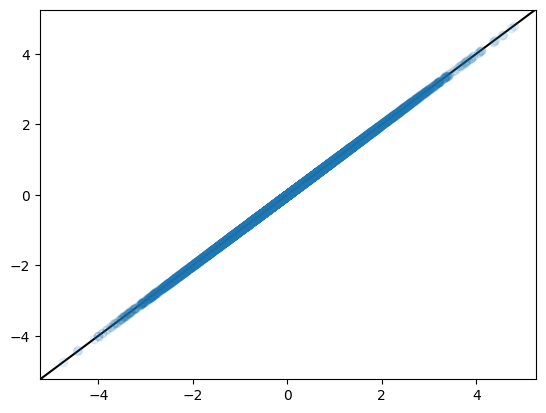

In [15]:
fig, ax = plt.subplots()
ax.scatter(forces_ref, calc_forces(pos, chg, nbl_no_duplicates), alpha=0.1)
plot_parity_line(ax, color="black", zorder=-1)
plt.show()

In [22]:
a = jax.device_put(pos)
b = jax.device_put(chg)
c = jax.device_put(nbl)

calc_energy(a, b, c).block_until_ready()
%timeit calc_energy(a, b, c).block_until_ready()

calc_forces(a, b, c).block_until_ready()
%timeit calc_forces(a, b, c).block_until_ready()

933 μs ± 12.5 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
3.09 ms ± 99.9 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [23]:
a = jax.device_put(pos)
b = jax.device_put(chg)
c = jax.device_put(nbl_no_duplicates)

calc_energy(a, b, c).block_until_ready()
%timeit calc_energy(a, b, c).block_until_ready()

calc_forces(a, b, c).block_until_ready()
%timeit calc_forces(a, b, c).block_until_ready()

861 μs ± 17.4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
2.65 ms ± 186 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
